In [1]:
from nsd_visuo_semantics.utils.nsd_prepare_modelrdms import nsd_prepare_modelrdms
from nsd_visuo_semantics.searchlight_analyses.nsd_searchlight_main_tf import nsd_searchlight_main_tf
from nsd_visuo_semantics.searchlight_analyses.nsd_project_fsaverage import nsd_project_fsaverage
from nsd_visuo_semantics.utils.py_plot_brain_utils import pyplot_brains_from_models_list
### DECLARE PARAMS
OVERWRITE = False
MODELS_RDM_DIST = "correlation"  # RDM distance measure for models NOTE: BRAIN RDMS ARE DONE WITH CORRELATION DISTANCE

I0000 00:00:1781271858.381520  191661 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781271858.385063  191661 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781271858.747363  191661 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781271859.714439  191661 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [2]:
base_save_dir = "./results"  # base dir from which to load model RDMs and in which to save results
nsd_dir = '/media/chuddy/120876114737F70A/data/NSD'
nsd_derivatives_dir = './results/searchlight/'  # we will put data modified from nsd here
betas_dir = f"{nsd_derivatives_dir}/betas"
precompsl_dir = f"{nsd_derivatives_dir}/searchlights"
figures_dir = f"{base_save_dir}/searchlight_respectedsampling_correlation/figures"
saved_embeddings_dir = f"{base_save_dir}/saved_embeddings"
rdms_dir = f'{base_save_dir}/serialised_models_{MODELS_RDM_DIST}'

In [3]:
models = ["fasttext_categories", "fasttext_verbs", "fasttext_nouns", "fasttext_all"]
nsd_prepare_modelrdms(models, MODELS_RDM_DIST, saved_embeddings_dir, rdms_dir, nsd_dir, "", "", True)

		sub: subj01 fetching condition trials in session: 20Creating fasttext_categories rdm for subj01
Saving in ./results/serialised_models_correlation/fasttext_categories/subj01_fasttext_categories_fullrdm.npy
		sub: subj01 fetching condition trials in session: 20Creating fasttext_verbs rdm for subj01
Saving in ./results/serialised_models_correlation/fasttext_verbs/subj01_fasttext_verbs_fullrdm.npy
		sub: subj01 fetching condition trials in session: 20Creating fasttext_nouns rdm for subj01
Saving in ./results/serialised_models_correlation/fasttext_nouns/subj01_fasttext_nouns_fullrdm.npy
		sub: subj01 fetching condition trials in session: 20Creating fasttext_all rdm for subj01
Saving in ./results/serialised_models_correlation/fasttext_all/subj01_fasttext_all_fullrdm.npy


In [3]:
models = ["all-mpnet-base-v2"]
nsd_prepare_modelrdms(models, MODELS_RDM_DIST, saved_embeddings_dir, rdms_dir, nsd_dir, "", "", True)

		sub: subj01 fetching condition trials in session: 20Creating all-mpnet-base-v2 rdm for subj01
Saving in ./results/serialised_models_correlation/all-mpnet-base-v2/subj01_all-mpnet-base-v2_fullrdm.npy


<Figure size 500x400 with 0 Axes>

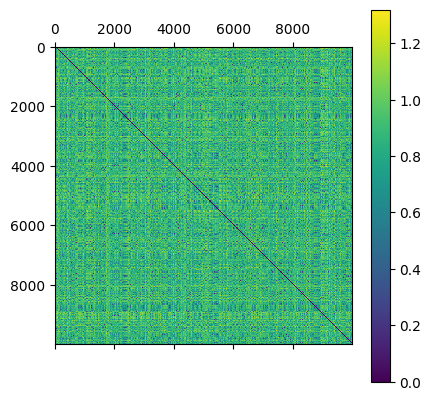

In [4]:
import os
import glob
import numpy as np

import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

model_name = "all-mpnet-base-v2"
rdm_dir = os.path.join(rdms_dir, model_name)
rdm_paths = sorted(glob.glob(os.path.join(rdm_dir, "*")))

for path in rdm_paths:
    rdm = np.load(path, allow_pickle=True)
    plt.figure(figsize=(5,4))
    plt.matshow(squareform(rdm))
    plt.colorbar()
    plt.show()
    break

In [4]:
betas = nsd_searchlight_main_tf(["all-mpnet-base-v2"], MODELS_RDM_DIST, 
                        nsd_dir, nsd_derivatives_dir, betas_dir, base_save_dir, 
                        OVERWRITE)

Starting main searchlight computations for all-mpnet-base-v2
Loading serialised model rdms from ./results/serialised_models_correlation/all-mpnet-base-v2
	the output files will be stored in ./results/searchlight_respectedsampling_correlation/subj01/all-mpnet-base-v2/corr_vols_correlation..
	looking for saved samples in ./results/searchlight_respectedsampling_correlation/subj01/saved_sampling..
	loading brain mask
	loading pre-computed searchlight
		sub: subj01 fetching condition trials in session: 20Running MPNET and DID NOT FIND existing saved_samples_file. Computing from scratch.
loading betas for subj01
loading betas for subj01


In [4]:
import numpy as np
np.int = int
nsd_project_fsaverage(["all-mpnet-base-v2"], MODELS_RDM_DIST, nsd_dir, base_save_dir)

	reading in ./results/searchlight_respectedsampling_correlation/subj01/all-mpnet-base-v2/corr_vols_correlation/subj01_nsd-all-mpnet-base-v2_func1pt8mm_sample-0.npy

reading model fit samples for all-mpnet-base-v2


samples: 100%|##########| 8/8 [00:00<00:00, 150.85it/s]

projecting to fsaverage

	projecting model 0 out of 1 models
data array passed



/home/chuddy/dev/neuroconnectionism/src/nsd_visuo_semantics/searchlight_analyses/nsd_project_fsaverage.py:103: RuntimeWarning: invalid value encountered in divide
  t_brain = np.nanmean(brain_vols, axis=0)/(np.nanstd(brain_vols, axis=0)/np.sqrt(n_samples))


data array passed
data array passed
data array passed
data array passed
data array passed
		saving ./results/searchlight_respectedsampling_correlation/subj01/all-mpnet-base-v2/all-mpnet-base-v2_correlation_fsaverage/{}.subj01-model-1-surf.npy to disk
data array passed
		saving ./results/searchlight_respectedsampling_correlation/subj01/all-mpnet-base-v2/all-mpnet-base-v2_correlation_fsaverage/{}.subj01-model-1-surf.npy to disk
data array passed
	projecting t-values for model 0 out of 1 models
data array passed
data array passed
data array passed
data array passed
data array passed
data array passed
		saving ./results/searchlight_respectedsampling_correlation/subj01/all-mpnet-base-v2/all-mpnet-base-v2_correlation_fsaverage/lh.subj01-model-1-surf-tvals.npy to disk
data array passed
		saving ./results/searchlight_respectedsampling_correlation/subj01/all-mpnet-base-v2/all-mpnet-base-v2_correlation_fsaverage/rh.subj01-model-1-surf-tvals.npy to disk
data array passed


In [5]:
import cortex
import os

fs_home = "/home/chuddy/dev/freesurfer"

os.environ["FREESURFER_HOME"] = fs_home
os.environ["FS_LICENSE"] = f"{fs_home}/license.txt"
os.environ["SUBJECTS_DIR"] = f"{fs_home}/subjects"
os.environ["PATH"] = f"{fs_home}/bin:" + os.environ["PATH"]

cortex.freesurfer.import_subj(
    "fsaverage",
    pycortex_subject="fsaverage",
    freesurfer_subject_dir=f"{fs_home}/subjects",
    whitematter_surf="white",
)

cortex.freesurfer.import_flat(
    "fsaverage",
    "cortex.patch",
    cx_subject="fsaverage",
    freesurfer_subject_dir=f"{fs_home}/subjects",
    auto_overwrite=True,
)

b'created by greve on Thu Apr 11 16:23:42 2013\n'
b'created by greve on Thu Jul 19 12:50:49 2018\n'
b'created by greve on Thu Apr 11 16:23:51 2013\n'
b'created by greve on Thu Jul 19 12:52:09 2018\n'
b'created by greve on Thu Apr 11 16:23:42 2013\n'
saving to /home/chuddy/dev/neuroconnectionism/.venv/share/pycortex/db/fsaverage/surfaces/flat_lh.gii
b'created by greve on Thu Apr 11 16:23:51 2013\n'
saving to /home/chuddy/dev/neuroconnectionism/.venv/share/pycortex/db/fsaverage/surfaces/flat_rh.gii


In [6]:
pyplot_brains_from_models_list(["all-mpnet-base-v2"], ["all-mpnet-base-v2"], f"{base_save_dir}/searchlight_respectedsampling_correlation",
                               layer='last', contrast_layer='same', 
                               contrast_same_model=False, max_cmap_val=None,
                               save_type='png', figpath=figures_dir, 
                               plot_indiv_sub=True, plot_subj_avg=False)

Generating a flatmap cache
